In [ ]:
%pip install ultralytics albumentations -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 8.2 MB/s eta 0:00:00


In [ ]:
import os
import random
import shutil
from pathlib import Path

import cv2
import yaml
import albumentations as A

from ultralytics import YOLO

print("Setup ready ✅")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Setup ready ✅


In [ ]:
!wget -O visual_pollution.zip "https://data.mendeley.com/public-files/datasets/bb7b8vtwry/files/71187f45-0159-4b87-94d7-ad0cca40bf31/file_downloaded"

--2026-10-07 19:30:06--  https://data.mendeley.com/public-files/datasets/bb7b8vtwry/files/71187f45-0159-4b87-94d7-ad0cca40bf31/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/381b10fe-76c0-4849-b433-3693070d4a48 [following]
--2026-10-07 19:30:07--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/381b10fe-76c0-4849-b433-3693070d4a48
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.73.106, 52.92.1.202, 3.5.64.216, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.73.106|:443... con

In [ ]:
!unzip -o -q visual_pollution.zip -d visual_pollution

In [ ]:
base = Path("/content/visual_pollution/Visual Pollution Dataset")

print("Main folders:")
for item in base.iterdir():
    print("-", item.name)

Main folders:
- images
- labels
- dataset.yaml


In [ ]:
print("Image folders:")
for p in (base / "images").iterdir():
    print("-", p.name)

print("\nLabel folders:")
for p in (base / "labels").iterdir():
    print("-", p.name)

Image folders:
- val
- train

Label folders:
- val
- train


In [ ]:
train_images = list((base / "images/train").glob("*"))
val_images = list((base / "images/val").glob("*"))

train_labels = list((base / "labels/train").glob("*.txt"))
val_labels = list((base / "labels/val").glob("*.txt"))

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Train labels:", len(train_labels))
print("Validation labels:", len(val_labels))

Train images: 24553
Validation images: 7242
Train labels: 24553
Validation labels: 7242


In [ ]:
with open(base / "dataset.yaml", "r") as f:
    print(f.read())

train: ../datasets/al_round_004/images/train
val: ../datasets/al_round_004/images/val

nc: 3
names: ['barriers', 'sidewalks', 'pothole']


In [ ]:
random.seed(42)

base = Path("/content/visual_pollution/Visual Pollution Dataset")

data = []

# نجمع train + val الأصليين
for source_split in ["train", "val"]:

    img_dir = base / "images" / source_split
    lbl_dir = base / "labels" / source_split

    for img_path in img_dir.iterdir():

        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        label_path = lbl_dir / f"{img_path.stem}.txt"

        if label_path.exists():
            data.append((source_split, img_path, label_path))

# خلط عشوائي ثابت
random.shuffle(data)

total = len(data)

n_train = int(total * 0.70)
n_val = int(total * 0.10)

splits = {
    "train": data[:n_train],
    "val": data[n_train:n_train+n_val],
    "test": data[n_train+n_val:]
}

new_base = base / "split_70_10_20"

# لو فيه تقسيم قديم نحذفه
if new_base.exists():
    shutil.rmtree(new_base)

# إنشاء المجلدات
for split in ["train", "val", "test"]:

    (new_base / "images" / split).mkdir(parents=True, exist_ok=True)
    (new_base / "labels" / split).mkdir(parents=True, exist_ok=True)

# نسخ الصور والـ labels بأسماء فريدة
for split, items in splits.items():

    for source_split, img_path, label_path in items:

        new_img_name = f"{source_split}_{img_path.name}"
        new_lbl_name = f"{source_split}_{label_path.name}"

        shutil.copy2(
            img_path,
            new_base / "images" / split / new_img_name
        )

        shutil.copy2(
            label_path,
            new_base / "labels" / split / new_lbl_name
        )

print("Total:", total)
print("Train:", len(splits["train"]))
print("Validation:", len(splits["val"]))
print("Test:", len(splits["test"]))

print("\nPercentages:")
print("Train:", round(len(splits["train"]) / total * 100, 2), "%")
print("Validation:", round(len(splits["val"]) / total * 100, 2), "%")
print("Test:", round(len(splits["test"]) / total * 100, 2), "%")

print("\nActual files:")
print("Train:", len(list((new_base / "images/train").iterdir())))
print("Validation:", len(list((new_base / "images/val").iterdir())))
print("Test:", len(list((new_base / "images/test").iterdir())))

Total: 31795
Train: 22256
Validation: 3179
Test: 6360

Percentages:
Train: 70.0 %
Validation: 10.0 %
Test: 20.0 %

Actual files:
Train: 22256
Validation: 3179
Test: 6360


In [ ]:
train_names = set(p.name for p in (new_base / "images/train").iterdir())
val_names = set(p.name for p in (new_base / "images/val").iterdir())
test_names = set(p.name for p in (new_base / "images/test").iterdir())

print("Train-Val overlap:", len(train_names & val_names))
print("Train-Test overlap:", len(train_names & test_names))
print("Val-Test overlap:", len(val_names & test_names))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [ ]:
# Paths
train_img_dir = new_base / "images/train"
train_lbl_dir = new_base / "labels/train"

aug_img_dir = new_base / "images/train_augmented"
aug_lbl_dir = new_base / "labels/train_augmented"

# Clean old augmented folders if they exist
if aug_img_dir.exists():
    shutil.rmtree(aug_img_dir)

if aug_lbl_dir.exists():
    shutil.rmtree(aug_lbl_dir)

aug_img_dir.mkdir(parents=True, exist_ok=True)
aug_lbl_dir.mkdir(parents=True, exist_ok=True)


# 6 Augmentation Strategies
transform = A.Compose([

    A.HorizontalFlip(p=0.5),                       # 1 Horizontal Flip

    A.RandomBrightnessContrast(
        brightness_limit=0.20,
        contrast_limit=0,
        p=0.4
    ),                                             # 2 Brightness

    A.RandomBrightnessContrast(
        brightness_limit=0,
        contrast_limit=0.20,
        p=0.4
    ),                                             # 3 Contrast

    A.Rotate(
        limit=10,
        p=0.3
    ),                                             # 4 Rotation

    A.Affine(
        scale=(0.90, 1.10),
        p=0.3
    ),                                             # 5 Scale

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.2
    )                                              # 6 Blur

],
bbox_params=A.BboxParams(
    format="yolo",
    label_fields=["class_labels"],
    min_visibility=0.2,
    clip=True
))

In [ ]:
def clean_box(x, y, w, h):
    x1 = max(0.0, min(1.0, x - w / 2))
    y1 = max(0.0, min(1.0, y - h / 2))
    x2 = max(0.0, min(1.0, x + w / 2))
    y2 = max(0.0, min(1.0, y + h / 2))

    if x2 <= x1 or y2 <= y1:
        return None

    return [
        (x1 + x2) / 2,
        (y1 + y2) / 2,
        x2 - x1,
        y2 - y1
    ]


image_files = [
    f for f in train_img_dir.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

for i, img_path in enumerate(image_files):

    label_path = train_lbl_dir / f"{img_path.stem}.txt"

    image = cv2.imread(str(img_path))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    bboxes = []
    class_labels = []

    if label_path.exists():

        with open(label_path, "r") as f:

            for line in f:

                values = line.strip().split()

                if len(values) == 5:

                    cls = int(float(values[0]))
                    x, y, w, h = map(float, values[1:])

                    box = clean_box(x, y, w, h)

                    if box is not None:
                        bboxes.append(box)
                        class_labels.append(cls)

    augmented = transform(
        image=image,
        bboxes=bboxes,
        class_labels=class_labels
    )

    aug_image = cv2.cvtColor(
        augmented["image"],
        cv2.COLOR_RGB2BGR
    )

    new_image_name = f"aug_{img_path.name}"

    cv2.imwrite(
        str(aug_img_dir / new_image_name),
        aug_image
    )

    new_label_path = (
        aug_lbl_dir /
        f"aug_{img_path.stem}.txt"
    )

    with open(new_label_path, "w") as f:

        for bbox, cls in zip(
            augmented["bboxes"],
            augmented["class_labels"]
        ):

            x, y, w, h = bbox

            f.write(
                f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n"
            )

    if (i + 1) % 1000 == 0:
        print("Processed:", i + 1)

print("Augmentation completed ✅")

Processed: 1000
Processed: 2000
Processed: 3000
Processed: 4000
Processed: 5000
Processed: 6000
Processed: 7000
Processed: 8000
Processed: 9000
Processed: 10000
Processed: 11000
Processed: 12000
Processed: 13000
Processed: 14000
Processed: 15000
Processed: 16000
Processed: 17000
Processed: 18000
Processed: 19000
Processed: 20000
Processed: 21000
Processed: 22000
Augmentation completed ✅


In [ ]:
print("Original Train Images:", len(list(train_img_dir.iterdir())))
print("Augmented Train Images:", len(list(aug_img_dir.iterdir())))
print("Original Train Labels:", len(list(train_lbl_dir.iterdir())))
print("Augmented Train Labels:", len(list(aug_lbl_dir.iterdir())))

Original Train Images: 22256
Augmented Train Images: 22256
Original Train Labels: 22256
Augmented Train Labels: 22256


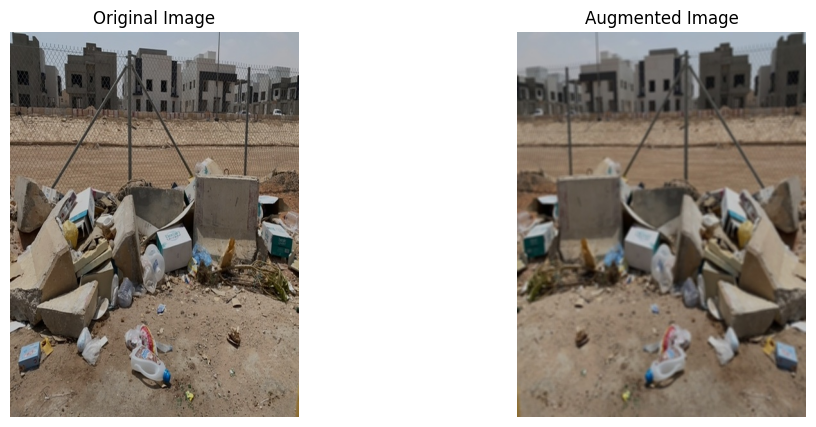

In [ ]:
import matplotlib.pyplot as plt
import random

sample_img = random.choice(list(train_img_dir.iterdir()))
sample_aug = aug_img_dir / f"aug_{sample_img.name}"

img1 = cv2.imread(str(sample_img))
img2 = cv2.imread(str(sample_aug))

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Augmented Image")
plt.axis("off")

plt.show()

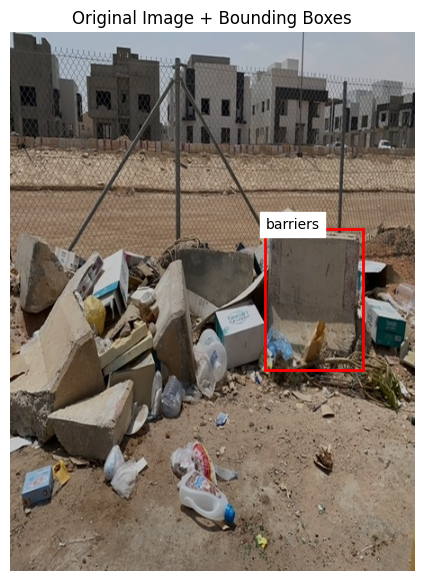

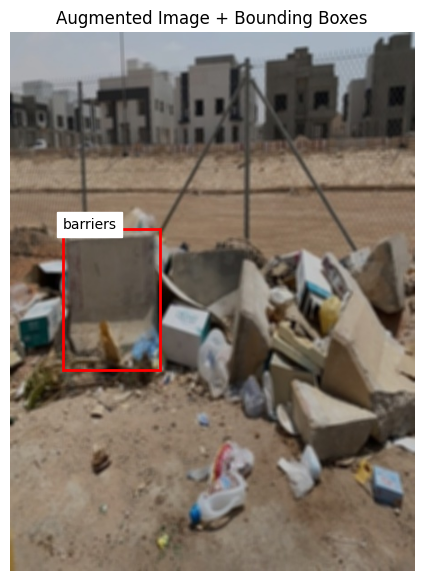

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class_names = ['barriers', 'sidewalks', 'pothole']

def show_yolo_boxes(image_path, label_path, title):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(image)

    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.strip().split())

                x *= w
                y *= h
                bw *= w
                bh *= h

                x1 = x - bw / 2
                y1 = y - bh / 2

                rect = patches.Rectangle(
                    (x1, y1),
                    bw,
                    bh,
                    linewidth=2,
                    edgecolor='red',
                    facecolor='none'
                )

                ax.add_patch(rect)
                ax.text(
                    x1,
                    y1,
                    class_names[int(cls)],
                    fontsize=10,
                    backgroundcolor='white'
                )

    ax.set_title(title)
    ax.axis("off")
    plt.show()


original_label = train_lbl_dir / f"{sample_img.stem}.txt"
aug_label = aug_lbl_dir / f"aug_{sample_img.stem}.txt"

show_yolo_boxes(sample_img, original_label, "Original Image + Bounding Boxes")
show_yolo_boxes(sample_aug, aug_label, "Augmented Image + Bounding Boxes")

In [ ]:
final_img_dir = new_base / "images/train_final"
final_lbl_dir = new_base / "labels/train_final"

if final_img_dir.exists():
    shutil.rmtree(final_img_dir)

if final_lbl_dir.exists():
    shutil.rmtree(final_lbl_dir)

final_img_dir.mkdir(parents=True, exist_ok=True)
final_lbl_dir.mkdir(parents=True, exist_ok=True)

# نسخ كل الصور الأصلية
for f in train_img_dir.iterdir():
    shutil.copy2(f, final_img_dir / f.name)

for f in train_lbl_dir.iterdir():
    shutil.copy2(f, final_lbl_dir / f.name)

# نختار نصف الصور الـ Augmented عشوائياً
random.seed(42)

aug_images = list(aug_img_dir.iterdir())
random.shuffle(aug_images)

selected_aug = aug_images[:11128]

for img_file in selected_aug:
    shutil.copy2(
        img_file,
        final_img_dir / img_file.name
    )

    label_file = aug_lbl_dir / f"{img_file.stem}.txt"

    if label_file.exists():
        shutil.copy2(
            label_file,
            final_lbl_dir / label_file.name
        )

print("Original images:", len(list(train_img_dir.iterdir())))
print("Selected augmented:", len(selected_aug))
print("Final Train Images:", len(list(final_img_dir.iterdir())))
print("Final Train Labels:", len(list(final_lbl_dir.iterdir())))

Original images: 22256
Selected augmented: 11128
Final Train Images: 33384
Final Train Labels: 33384


In [ ]:
dataset_yaml = new_base / "dataset_final.yaml"

with open(dataset_yaml, "w") as f:
    f.write(
f"""train: {new_base / "images/train_final"}
val: {new_base / "images/val"}
test: {new_base / "images/test"}

nc: 3
names: ['barriers', 'sidewalks', 'pothole']
"""
    )

print("dataset_final.yaml created ✅")
print(dataset_yaml.read_text())

dataset_final.yaml created ✅
train: /content/visual_pollution/Visual Pollution Dataset/split_70_10_20/images/train_final
val: /content/visual_pollution/Visual Pollution Dataset/split_70_10_20/images/val
test: /content/visual_pollution/Visual Pollution Dataset/split_70_10_20/images/test

nc: 3
names: ['barriers', 'sidewalks', 'pothole']



In [ ]:
print("Train images:", len(list((new_base / "images/train_final").iterdir())))
print("Train labels:", len(list((new_base / "labels/train_final").iterdir())))
print("Validation images:", len(list((new_base / "images/val").iterdir())))
print("Validation labels:", len(list((new_base / "labels/val").iterdir())))
print("Test images:", len(list((new_base / "images/test").iterdir())))
print("Test labels:", len(list((new_base / "labels/test").iterdir())))

Train images: 33384
Train labels: 33384
Validation images: 3179
Validation labels: 3179
Test images: 6360
Test labels: 6360


In [ ]:
model = YOLO("yolo11n.pt")

results = model.train(
    data=str(dataset_yaml),
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    workers=0
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visual_pollution/Visual Pollution Dataset/split_70_10_20/dataset_final.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=trai

In [ ]:
best_model = YOLO("/content/runs/detect/train/weights/best.pt")

test_results = best_model.val(
    data=str(dataset_yaml),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    workers=0,
    plots=True
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.8±1.6 ms, read: 16.2±7.2 MB/s, size: 98.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/visual_pollution/Visual Pollution Dataset/split_70_10_20/labels/test... 6360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6360/6360 448.6it/s 14.2s
val: New cache created: /content/visual_pollution/Visual Pollution Dataset/split_70_10_20/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 398/398 4.8it/s 1:23
                   all       6360       8463      0.622       0.62      0.651      0.422
              barriers       1252       1649      0.571      0.586      0.593      0.416
     

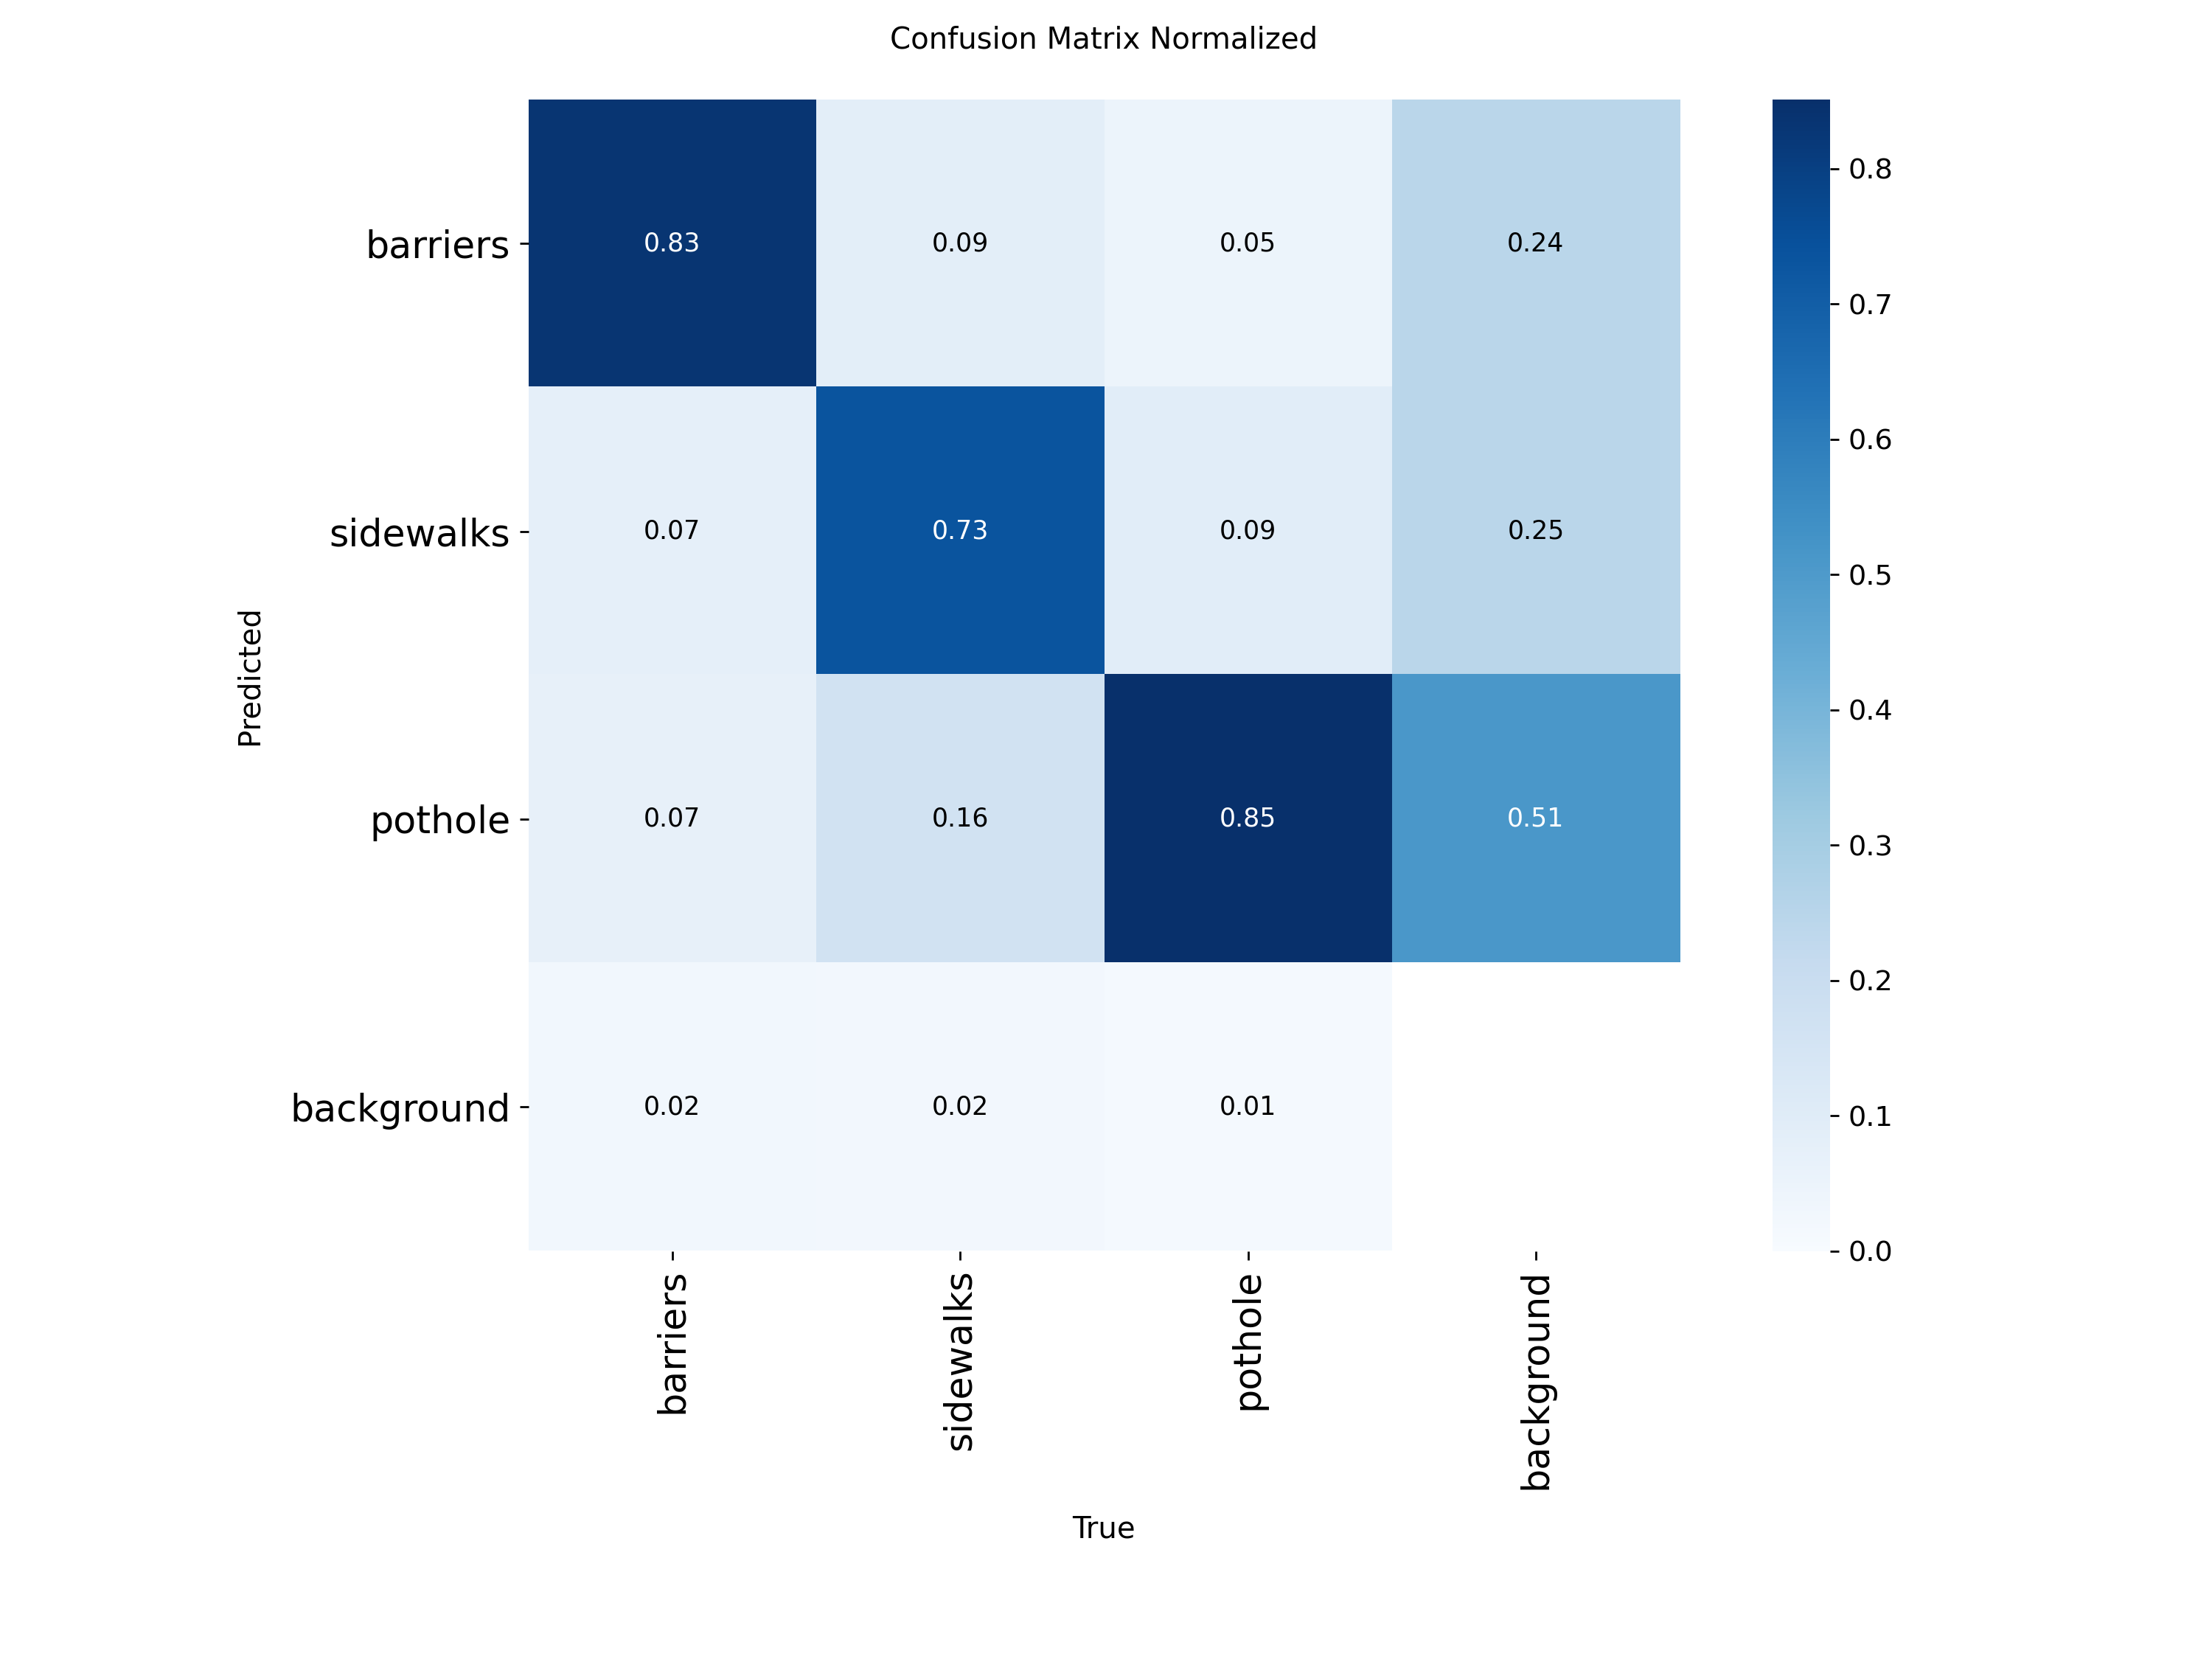

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/val/confusion_matrix_normalized.png"))

In [ ]:
test_images = list((new_base / "images/test").iterdir())
sample_images = random.sample(test_images, 6)

predictions = best_model.predict(
    source=[str(img) for img in sample_images],
    imgsz=640,
    conf=0.25,
    device=0,
    save=True
)


0: 640x640 (no detections), 6.5ms
1: 640x640 1 pothole, 6.5ms
2: 640x640 (no detections), 6.5ms
3: 640x640 1 sidewalks, 6.5ms
4: 640x640 1 pothole, 6.5ms
5: 640x640 1 sidewalks, 1 pothole, 6.5ms
Speed: 3.0ms preprocess, 6.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


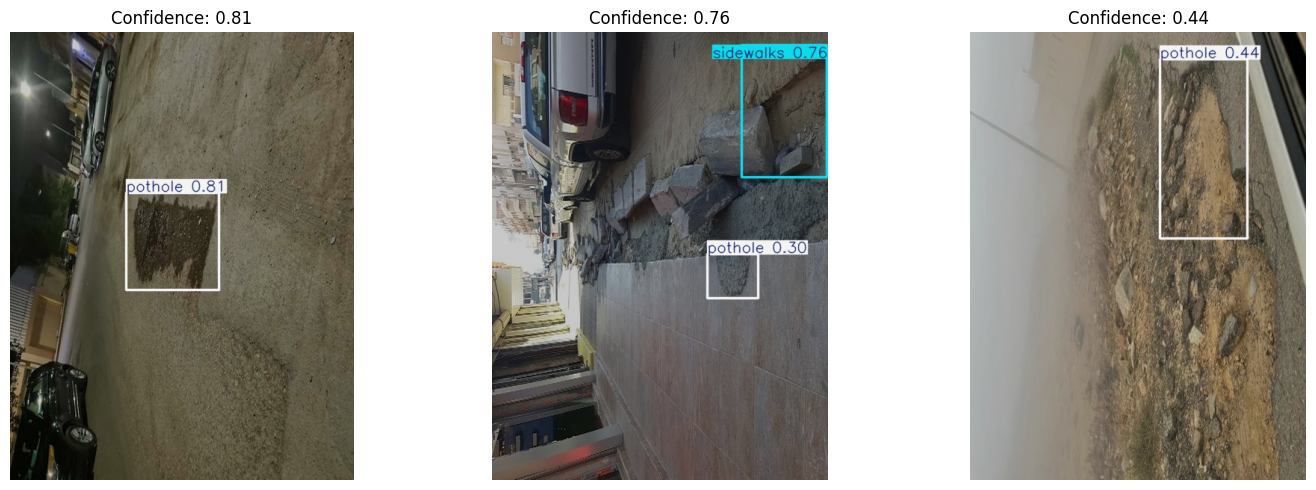

In [ ]:
import matplotlib.pyplot as plt

# ترتيب نتائج التوقع حسب أعلى Confidence
ranked = []

for result in predictions:
    if result.boxes is not None and len(result.boxes) > 0:
        max_conf = float(result.boxes.conf.max())
        ranked.append((max_conf, result))

# ترتيب من الأعلى للأقل
ranked.sort(key=lambda x: x[0], reverse=True)

# عرض أفضل 3 صور فقط
plt.figure(figsize=(15, 5))

for i, (conf, result) in enumerate(ranked[:3]):
    img = result.plot()[:, :, ::-1]  # تحويل BGR إلى RGB

    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Confidence: {conf:.2f}")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download("/content/runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q gradio==6.21.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.1 MB/s eta 0:00:00


In [ ]:
import cv2
from PIL import Image
from ultralytics import YOLO

# تحميل أفضل مودل دربناه
WEIGHTS = "/content/runs/detect/train/weights/best.pt"

model = YOLO(WEIGHTS)

# أسماء الفئات من المودل
CLASSES = [model.names[i] for i in sorted(model.names)]

def draw(result):
    return Image.fromarray(
        cv2.cvtColor(
            result.plot(line_width=3),
            cv2.COLOR_BGR2RGB
        )
    )

print("Model:", WEIGHTS)
print("Classes:", CLASSES)

Model: /content/runs/detect/train/weights/best.pt
Classes: ['barriers', 'sidewalks', 'pothole']


In [1]:
import gradio as gr

def detect_image(img):
    if img is None:
        return None, "حالة البلاغ: لم يتم إدخال أو رفع أي صورة."

    # تشغيل المودل
    result = model.predict(
        img,
        conf=0.25,
        verbose=False
    )[0]

    # رسم الـ Bounding Boxes
    plotted_img = result.plot()

    # استخراج أسماء الفئات المكتشفة
    detected_classes = [
        result.names[int(cls)]
        for cls in result.boxes.cls
    ]

    if detected_classes:
        classes_set = set(detected_classes)
        descriptions = []

        for c in classes_set:
            c_lower = c.lower()

            if "pothole" in c_lower:
                descriptions.append(
                    "تم رصد حفرة أو تلف في سطح الطريق، "
                    "ويُنصح بإحالته للمراجعة والصيانة البلدية."
                )

            elif "barrier" in c_lower:
                descriptions.append(
                    "تم رصد عائق أو حاجز في الطريق قد يؤثر "
                    "على حركة المركبات أو المشاة."
                )

            elif "sidewalk" in c_lower:
                descriptions.append(
                    "تم رصد تلف أو ضرر في الرصيف، "
                    "ويُنصح بمراجعته لأعمال الصيانة."
                )

            else:
                descriptions.append(
                    f"تم رصد عيب بلدي من النوع: {c}."
                )

        details = "\n".join(f"- {d}" for d in descriptions)

        report_type = (
            "حالة البلاغ: تم رصد مشكلة بلدية في الصورة.\n\n"
            f"نوع الضرر المكتشف: {', '.join(classes_set)}\n\n"
            f"التفاصيل:\n{details}"
        )

    else:
        report_type = (
            "حالة البلاغ: لم يتم رصد أي من أنواع الأضرار "
            "التي تم تدريب النموذج عليها في هذه الصورة."
        )

    return plotted_img, report_type


demo = gr.Interface(
    fn=detect_image,

    inputs=gr.Image(
        type="pil",
        sources=["upload", "webcam"],
        label="رفع صورة أو التقاط صورة بالكاميرا"
    ),

    outputs=[
        gr.Image(
            label="نتيجة الكشف"
        ),

        gr.Textbox(
            label="تقرير البلاغ البلدي",
            lines=8
        )
    ],

    title="Smart Municipal Complaint Assistant",

    description=(
        "نظام مساعد للبلاغات البلدية يستخدم الرؤية الحاسوبية "
        "للكشف عن الحفر والعوائق وتلف الأرصفة وإصدار وصف أولي للبلاغ."
    )
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8db8a913a9c7eb589f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
